# Pokémon Veri Seti Üzerinde Doğrusal Model Analizi (F Testi)

Bu çalışmada Pokémon veri seti kullanılarak, nicel bir değişken olan *capture_rate* ile iki farklı nitel değişken (*is_legendary* ve *color*) arasındaki ilişkiler incelenmiştir.

Amaç, bu gruplar arasında istatistiksel olarak anlamlı fark olup olmadığını F testi (ANOVA) ile analiz etmektir.

## Veri Setinin Oluşturulması

Bu bölümde Pokémon verileri PokeAPI üzerinden çekilmiş ve analiz için uygun hale getirilmiştir.

Veri setinde aşağıdaki değişkenler bulunmaktadır:

- **name**: Pokémon ismi  
- **capture_rate**: Yakalanma zorluğunu temsil eden nicel değişken  
- **is_legendary**: Pokémon'un efsanevi olup olmadığını belirten kategorik değişken  
- **color**: Pokémon’un renk kategorisi (çok kategorili nitel değişken)

In [1]:
import requests
import pandas as pd

url = "https://pokeapi.co/api/v2/pokemon-species?limit=151"
response = requests.get(url)
data = response.json()

species_list= data["results"]
rows = []

for pokemon in species_list:
    detail_response = requests.get(pokemon["url"])
    detail = detail_response.json()

    rows.append({
                "name":detail["name"],
                 "capture_rate":detail["capture_rate"],
                 "is_legendary":detail["is_legendary"],
                 "color": detail["color"]["name"] if detail["color"] else None
                 })

df = pd.DataFrame(rows)

## Veri Setinin İncelenmesi

Veri setinde eksik değer kontrolü yapılmış ve değişken tipleri incelenmiştir.

Sonuçlara göre veri setinde eksik değer bulunmamaktadır ve analiz için uygun durumdadır.

In [2]:
print(df.isna().sum())
print(df.info())
print(df.head())

name            0
capture_rate    0
is_legendary    0
color           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   name          151 non-null    object
 1   capture_rate  151 non-null    int64 
 2   is_legendary  151 non-null    bool  
 3   color         151 non-null    object
dtypes: bool(1), int64(1), object(2)
memory usage: 3.8+ KB
None
         name  capture_rate  is_legendary  color
0   bulbasaur            45         False  green
1     ivysaur            45         False  green
2    venusaur            45         False  green
3  charmander            45         False    red
4  charmeleon            45         False    red


In [3]:
df.to_csv("pokemon_species.csv",index=False)
df = pd.read_csv("pokemon_species.csv")
df

,name,capture_rate,is_legendary,color
0,bulbasaur,45,False,green
1,ivysaur,45,False,green
2,venusaur,45,False,green
3,charmander,45,False,red
4,charmeleon,45,False,red
...,...,...,...,...
146,dratini,45,False,blue
147,dragonair,45,False,blue
148,dragonite,45,False,brown
149,mewtwo,3,True,purple


## A) Efsanevi Duruma Göre Yakalanma Oranı Analizi

Bu bölümde Pokémon’ların efsanevi olup olmamasına göre yakalanma oranlarının dağılımı incelenmiştir.

Boxplot grafiği kullanılarak iki grup arasındaki fark görsel olarak değerlendirilmiştir.

<Figure size 800x600 with 0 Axes>

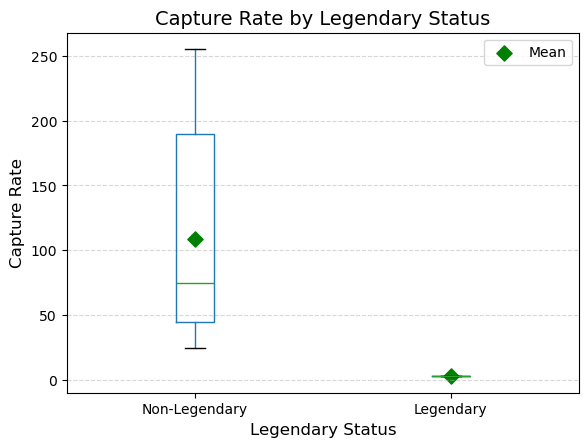

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

df.boxplot(
    column="capture_rate",
    by="is_legendary",
    grid=False
)

means = df.groupby("is_legendary")["capture_rate"].mean()

plt.scatter(
    [1, 2],
    means,
    color="green",
    marker="D",
    s=60,
    label="Mean"
)

plt.title("Capture Rate by Legendary Status", fontsize=14)
plt.suptitle("")
plt.xlabel("Legendary Status", fontsize=12)
plt.ylabel("Capture Rate", fontsize=12)
plt.xticks([1,2], ["Non-Legendary", "Legendary"])
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()

plt.show()

### Grafik Yorumu

Grafik incelendiğinde, efsanevi olmayan Pokémon’ların yakalanma oranlarının daha geniş bir aralıkta ve genellikle daha yüksek olduğu görülmektedir.

Efsanevi Pokémon’ların ise oldukça düşük yakalanma oranlarına sahip olduğu ve dar bir aralıkta yoğunlaştığı gözlemlenmiştir.

Bu durum, iki grup arasında belirgin bir fark olabileceğine işaret etmektedir.

## B) Renk Kategorisine Göre Yakalanma Oranı Analizi

Bu bölümde Pokémon’ların renk kategorilerine göre yakalanma oranlarının dağılımı incelenmiştir.

Boxplot grafiği ile farklı renk grupları arasındaki dağılım görselleştirilmiştir.

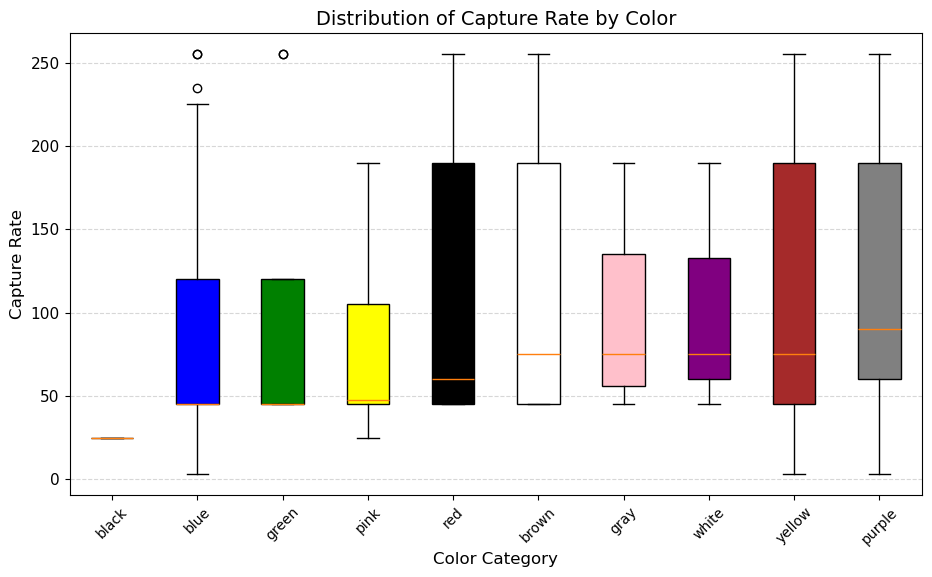

In [6]:
color_order = (
    df.groupby("color")["capture_rate"]
    .median()
    .sort_values()
    .index
    .tolist()
)

data_to_plot = [
    df[df["color"] == color]["capture_rate"]
    for color in color_order
]

plt.figure(figsize=(11, 6))

box = plt.boxplot(
    data_to_plot,
    tick_labels=color_order,
    patch_artist=True
)

color_map = {
    "red": "red",
    "blue": "blue",
    "green": "green",
    "yellow": "yellow",
    "black": "black",
    "white": "lightgray",
    "pink": "pink",
    "purple": "purple",
    "brown": "saddlebrown",
    "gray": "gray"
}

for patch, color in zip(box["boxes"], color_map):
    patch.set_facecolor(color)

plt.title("Distribution of Capture Rate by Color", fontsize=14)
plt.xlabel("Color Category", fontsize=12)
plt.ylabel("Capture Rate", fontsize=12)
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Grafik Yorumu

Grafik incelendiğinde, farklı renk kategorilerinde medyan ve yayılım açısından bazı farklılıklar gözlemlenmektedir.

Ancak bu farkların tutarlı ve belirgin bir yapı oluşturmadığı dikkat çekmektedir.

Bazı renk gruplarında gözlem sayısının düşük olması da dağılımın dar görünmesine neden olmaktadır.

In [7]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

model_a = smf.ols("capture_rate ~ C(is_legendary)", data=df).fit()
anova_a = anova_lm(model_a)

model_b = smf.ols("capture_rate ~ C(color)", data=df).fit()
anova_b = anova_lm(model_b)

print(anova_a)
print(anova_b)

                    df         sum_sq       mean_sq         F    PR(>F)
C(is_legendary)    1.0   43747.814750  43747.814750  7.686232  0.006275
Residual         149.0  848064.993197   5691.711364       NaN       NaN
             df         sum_sq      mean_sq         F    PR(>F)
C(color)    9.0   31575.382512  3508.375835  0.575052  0.815837
Residual  141.0  860237.425435  6100.974648       NaN       NaN


### F Testi Sonucu

Efsanevi ve efsanevi olmayan Pokémon’lar arasında fark olup olmadığını test etmek için ANOVA (F testi) uygulanmıştır.

Elde edilen p-değeri:

- **p = 0.006**

Bu değer 0.05 anlamlılık düzeyinden küçük olduğu için:

👉 Gruplar arasında istatistiksel olarak anlamlı fark bulunmaktadır.

Sonuç olarak, efsanevi Pokémon’ların yakalanma oranlarının anlamlı şekilde daha düşük olduğu söylenebilir.



Renk kategorileri arasında yakalanma oranı bakımından anlamlı fark olup olmadığını test etmek için ANOVA uygulanmıştır.

Elde edilen p-değeri:

- **p = 0.816**

Bu değer 0.05 anlamlılık düzeyinden büyük olduğu için:

👉 Renk kategorileri arasında istatistiksel olarak anlamlı bir fark bulunmamaktadır.

Sonuç olarak, Pokémon’un rengi yakalanma oranı üzerinde anlamlı bir etkiye sahip değildir.